In [3]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns


In [4]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [5]:
origin = load_data("boston")


print("\n====데이터타입확인=====")
print(f"데이터셋 크기:{origin.shape}")
print(f"열 개수:{origin.shape[1]}")
print(f"행 개수:{origin.shape[0]}")

print("=====타입확인=====")
print(origin.info())

[data] https://data.hossam.kr/data/kaggle/boston.xlsx
[desc] 보스턴 인근 지역의 인구·환경·교육·범죄·세금 정보 등을 기반으로 주택의 중위가격(MEDV)을 예측하기 위해 수집된 대표적인 회귀 분석용 주택시장 데이터 (출처: https://www.kaggle.com/datasets/altavish/boston-housing-dataset)

field    description
-------  ---------------------------------------------------------------------------------------
CRIM     타운별 1인당 범죄율 (Per capita crime rate by town)
ZN       25,000 sqft 이상 주거용 대지 비율 (Proportion of residential land zoned for large lots)
INDUS    비소매 상업구역 비율 (Proportion of non-retail business acres per town)
CHAS     찰스강 인접 여부 (Charles River dummy variable: 1 if tract bounds river; 0 otherwise)
NOX      대기 오염 정도 (Nitric oxides concentration, parts per 10 million)
RM       주택당 평균 방(Room) 수 (Average number of rooms per dwelling)
AGE      1940년 이전 건축 비율 (Proportion of owner-occupied units built prior to 1940)
DIS      5개 주요 고용센터까지의 거리 (Weighted distances to five Boston employment centers)
RAD      고속도로 접근성 지수 (Index of accessibility to radial highways)
T

In [6]:

print(f"타입확인")
print({origin.info()})

타입확인
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
{None}


In [7]:
import numpy as np
col_desc = {
    'CRIM': '타운별 1인당 범죄율 (Per capita crime rate by town)',
    'ZN': '25,000 sqft 이상 주거용 대지 비율 (Proportion of residential land zoned for large lots)',
    'INDUS': '비소매 상업지역 비율 (Proportion of non-retail business acres per town)',
    'CHAS': '찰스강 인접 여부 (1이면 강 인접, 0이면 비인접)',
    'NOX': '대기 오염 정도 (Nitric oxides concentration, parts per 10 million)',
    'RM': '주택당 평균 방 수 (Average number of rooms per dwelling)',
    'AGE': '1940년 이전 건축 비율 (Proportion of owner-occupied units built prior to 1940)',
    'DIS': '5개 주요 고용센터까지의 거리 (Weighted distances to five Boston employment centers)',
    'RAD': '고속도로 접근성 지수 (Index of accessibility to radial highways)',
    'TAX': '재산세율 (Full-value property-tax rate per $10,000)',
    'PTRATIO': '학생-교사 비율 (Pupil-teacher ratio by town)',
    'B': '흑인 비율 지수 (1000(Bk − 0.63)², Bk = proportion of Black residents)',
    'LSTAT': '저소득층 비율 (%) (Percentage of lower status population)',
    'MEDV': '주택 가격 중앙값 (단위: $1,000)'
}


for col, desc in col_desc.items():
    print(f'[{col}]')
    print(desc)
    print('-' * 60)
# 변수를 사용하는 경우origin[numeric]
numeric = ['ZN', 'INDUS', 'NOX','RM','AGE','DIS','PTRATIO','B','LSTAT']

log = np.log(origin[numeric])
log.describe()

[CRIM]
타운별 1인당 범죄율 (Per capita crime rate by town)
------------------------------------------------------------
[ZN]
25,000 sqft 이상 주거용 대지 비율 (Proportion of residential land zoned for large lots)
------------------------------------------------------------
[INDUS]
비소매 상업지역 비율 (Proportion of non-retail business acres per town)
------------------------------------------------------------
[CHAS]
찰스강 인접 여부 (1이면 강 인접, 0이면 비인접)
------------------------------------------------------------
[NOX]
대기 오염 정도 (Nitric oxides concentration, parts per 10 million)
------------------------------------------------------------
[RM]
주택당 평균 방 수 (Average number of rooms per dwelling)
------------------------------------------------------------
[AGE]
1940년 이전 건축 비율 (Proportion of owner-occupied units built prior to 1940)
------------------------------------------------------------
[DIS]
5개 주요 고용센터까지의 거리 (Weighted distances to five Boston employment centers)
----------------------------------------------------

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,ZN,INDUS,NOX,RM,AGE,DIS,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,-inf,2.160192,-0.610026,1.831864,4.090803,1.188032,2.907914,5.749869,2.370965
std,NaN,0.776987,0.201483,0.112325,0.610740,0.539547,0.124821,0.773471,0.600891
min,-inf,-0.776529,-0.954512,1.270041,1.064711,0.121864,2.533697,-1.139434,0.548121
25%,NaN,1.646734,-0.800732,1.772492,3.807217,0.742021,2.856470,5.927932,1.938729
50%,NaN,2.271094,-0.619897,1.825919,4.350275,1.165473,2.947064,5.969832,2.430097
75%,2.525729,2.895912,-0.471605,1.890624,4.544092,1.646399,3.005683,5.981982,2.830563
max,4.605170,3.322875,-0.138113,2.172476,4.605170,2.495393,3.091042,5.983684,3.636796


In [8]:
for col, desc in col_desc.items():
    print(f'[{col}]')
    print(desc)
    print('-' * 60)

[CRIM]
타운별 1인당 범죄율 (Per capita crime rate by town)
------------------------------------------------------------
[ZN]
25,000 sqft 이상 주거용 대지 비율 (Proportion of residential land zoned for large lots)
------------------------------------------------------------
[INDUS]
비소매 상업지역 비율 (Proportion of non-retail business acres per town)
------------------------------------------------------------
[CHAS]
찰스강 인접 여부 (1이면 강 인접, 0이면 비인접)
------------------------------------------------------------
[NOX]
대기 오염 정도 (Nitric oxides concentration, parts per 10 million)
------------------------------------------------------------
[RM]
주택당 평균 방 수 (Average number of rooms per dwelling)
------------------------------------------------------------
[AGE]
1940년 이전 건축 비율 (Proportion of owner-occupied units built prior to 1940)
------------------------------------------------------------
[DIS]
5개 주요 고용센터까지의 거리 (Weighted distances to five Boston employment centers)
----------------------------------------------------

In [9]:

log = np.log1p(origin[numeric])
log_desc = log.describe()

orig_scale_mean = np.expm1(log_desc.loc['mean'])

orig_scale_mean

ZN           1.595743
INDUS        8.995040
NOX          0.550515
RM           6.250999
AGE         60.075089
DIS          3.391398
PTRATIO     18.326214
B          316.193288
LSTAT       10.888955
Name: mean, dtype: float64

In [10]:
import numpy as np

log_values = [0, 0.3, 0.55, 0.7]

table = {v: np.exp(v) for v in log_values}
table

{0: np.float64(1.0),
 0.3: np.float64(1.3498588075760032),
 0.55: np.float64(1.7332530178673953),
 0.7: np.float64(2.0137527074704766)}

INDUS<br>
0~2 → 거의 주거 중심<br> 
5 전후 → 주거 + 상업 혼합<br> 
8~9 → 상업·산업 활동이 꽤 많은 지역<br> 
15 이상 → 산업 중심 지역<br>
MEDV와 선형으로 잡기 좋은 상태<br>

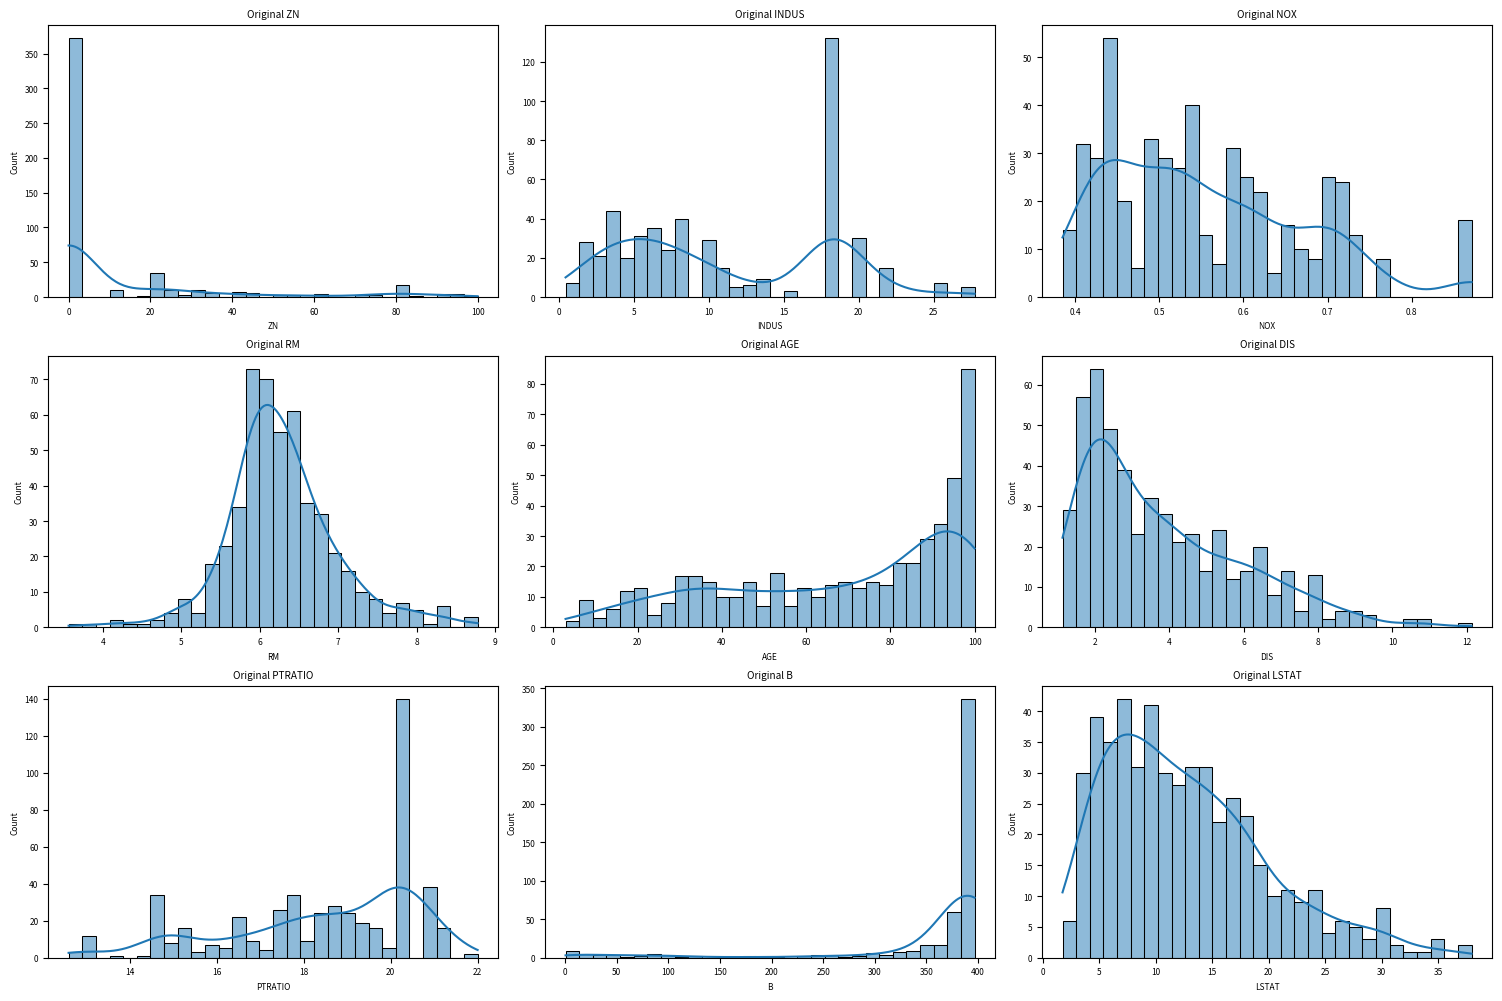

In [11]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric, 1):
    plt.subplot(3, 3, i)
    sns.histplot(origin[col], bins=30,kde=True)
    plt.title(f'Original {col}')

plt.tight_layout()
plt.show()


공부

In [26]:

data = [1,2,3,4,5] 

for i in data:
    total = 0
    total += i
total = sum(data)
total

15

In [33]:
data = ['apple','banana','cherry']

for i, value in enumerate(data):
    print(i, value)

0 apple
1 banana
2 cherry


In [35]:
numbers = [1,2,3,4]
for idx, value in enumerate(numbers):
    numbers[idx] = value * 2

print(numbers)

[2, 4, 6, 8]


In [37]:
names = ['Kim', 'Lee','Park']

for idx, name in enumerate(names, start =1):
    print(f"{idx}번: {name}")

1번: Kim
2번: Lee
3번: Park


In [ ]:
scores = [70,80,90,60]

for idx, 